In [20]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import geopandas as gpd
import folium
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score
import joblib

# Load the original dataset
data = pd.read_csv("unified_dataset.csv")

# Display the first few rows and info
print(data.info())
data.head()



<class 'pandas.core.frame.DataFrame'>
RangeIndex: 162 entries, 0 to 161
Data columns (total 15 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   quadkey              162 non-null    int64  
 1   avg_d_kbps           162 non-null    int64  
 2   avg_u_kbps           162 non-null    int64  
 3   avg_lat_ms           162 non-null    int64  
 4   tests                162 non-null    int64  
 5   devices              162 non-null    int64  
 6   geometry             162 non-null    object 
 7   index_right          162 non-null    int64  
 8   longitude            162 non-null    float64
 9   latitude             162 non-null    float64
 10  light intensity      162 non-null    float64
 11  year                 162 non-null    int64  
 12  annual radiance      162 non-null    float64
 13  percentage           108 non-null    float64
 14  GDP_at_Market_Price  162 non-null    float64
dtypes: float64(6), int64(8), object(1)
memor

,quadkey,avg_d_kbps,avg_u_kbps,avg_lat_ms,tests,devices,geometry,index_right,longitude,latitude,light intensity,year,annual radiance,percentage,GDP_at_Market_Price
0,3011001113313200,55129,9088,25,7,6,"POLYGON ((73.0810546875 -0.593251118140868, 73...",84617,73.083333,-0.595833,12.01,2022,0.016455,58.551126,2.3
1,3011001113313200,55129,9088,25,7,6,"POLYGON ((73.0810546875 -0.593251118140868, 73...",38717,73.083333,-0.595833,11.47,2021,0.010378,NaN,55.3
2,3011001113313200,55129,9088,25,7,6,"POLYGON ((73.0810546875 -0.593251118140868, 73...",130517,73.083333,-0.595833,12.16,2023,0.014641,-11.024904,4.0
3,3011001113313202,80652,21890,20,1,1,"POLYGON ((73.0810546875 -0.598743985012525, 73...",131057,73.083333,-0.604167,2.51,2023,0.014641,-11.024904,4.0
4,3011001113313202,80652,21890,20,1,1,"POLYGON ((73.0810546875 -0.598743985012525, 73...",130787,73.083333,-0.600000,7.70,2023,0.014641,-11.024904,4.0


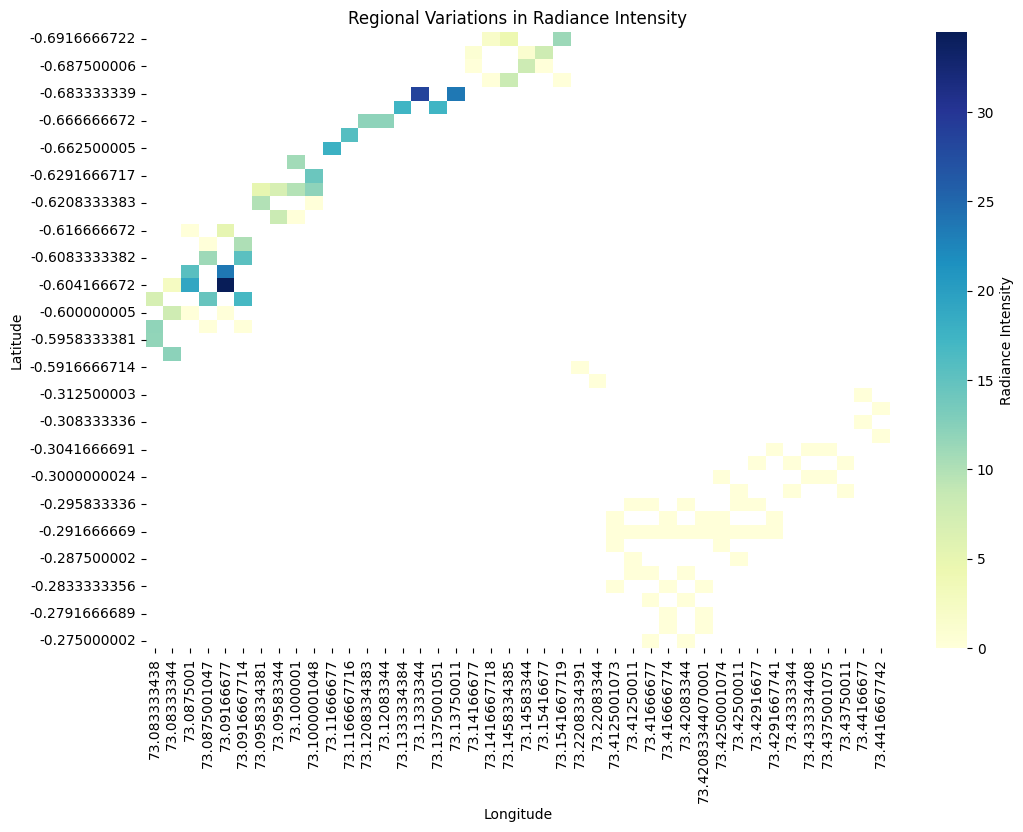

In [5]:
# Pivot data for radiance intensity
heatmap_data = data.pivot_table(index='latitude', columns='longitude', values='light intensity')

# Plot heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(heatmap_data, cmap='YlGnBu', cbar_kws={'label': 'Radiance Intensity'})
plt.title("Regional Variations in Radiance Intensity")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.show()


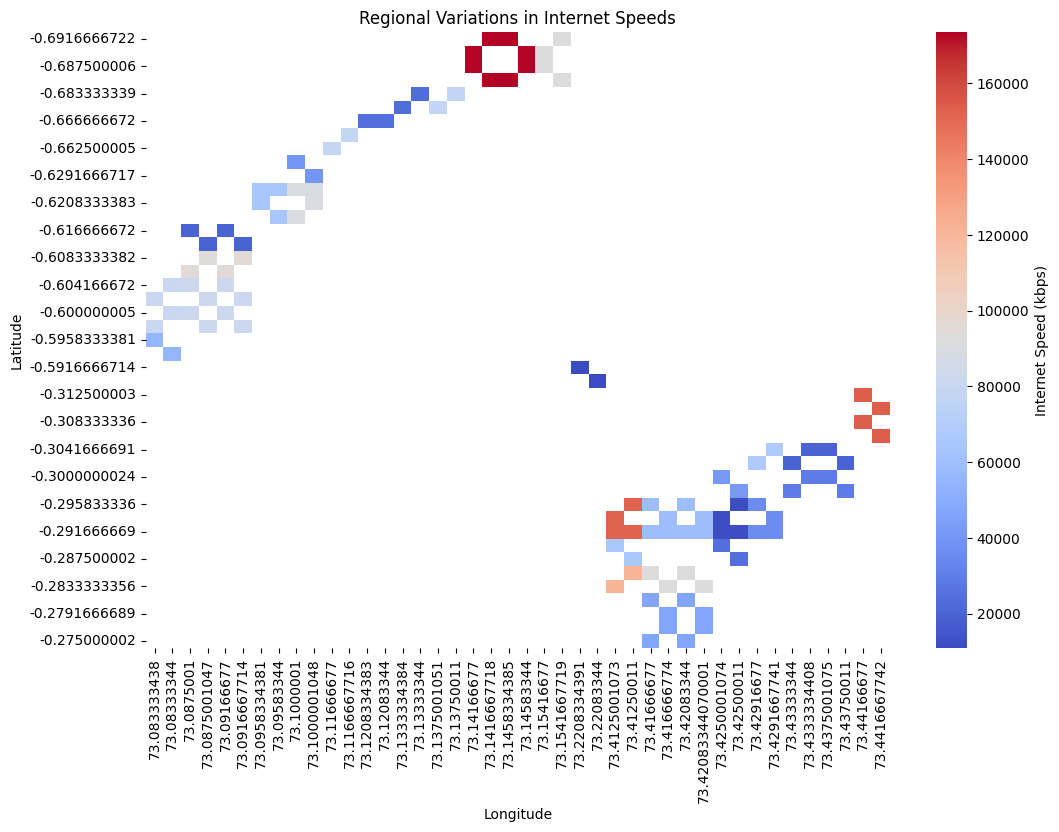

In [6]:
# Pivot data for internet speeds
heatmap_data_speed = data.pivot_table(index='latitude', columns='longitude', values='avg_d_kbps')

# Plot heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(heatmap_data_speed, cmap='coolwarm', cbar_kws={'label': 'Internet Speed (kbps)'})
plt.title("Regional Variations in Internet Speeds")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.show()


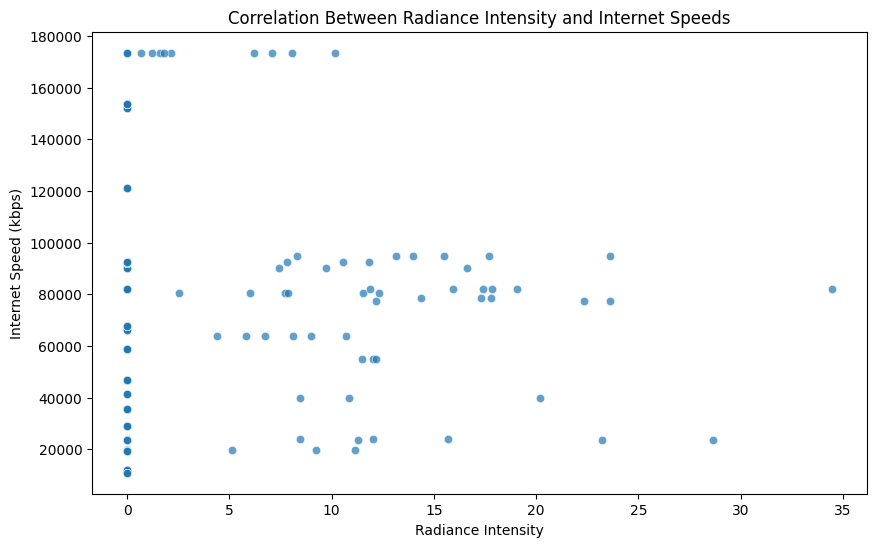

In [7]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x='light intensity', y='avg_d_kbps', data=data, alpha=0.7)
plt.title("Correlation Between Radiance Intensity and Internet Speeds")
plt.xlabel("Radiance Intensity")
plt.ylabel("Internet Speed (kbps)")
plt.show()


In [15]:
# Check for missing or zero values
print(data['light intensity'].isnull().sum())
print((data['light intensity'] == 0).sum())

# Remove rows with missing or zero values
data = data[data['light intensity'] > 0]


0
102


In [16]:
data['light_bin'] = pd.qcut(data['light intensity'], q=4, labels=['Low', 'Medium', 'High', 'Very High'], duplicates='drop')


<ipython-input-16-bebc28a83da6>:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data['light_bin'] = pd.qcut(data['light intensity'], q=4, labels=['Low', 'Medium', 'High', 'Very High'], duplicates='drop')


<ipython-input-17-ea4fe0956c04>:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  bar_data = data.groupby('light_bin')['avg_d_kbps'].mean().reset_index()
<ipython-input-17-ea4fe0956c04>:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='light_bin', y='avg_d_kbps', data=bar_data, palette='Blues_d')


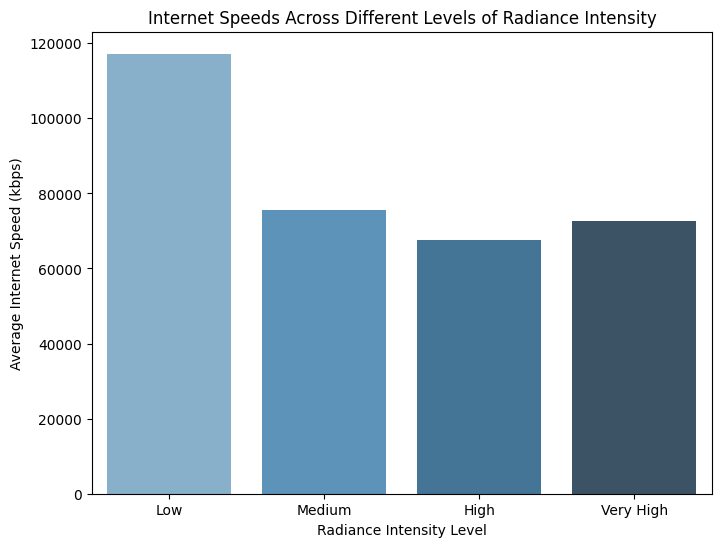

In [17]:
# Group by light_bin and calculate mean internet speeds
bar_data = data.groupby('light_bin')['avg_d_kbps'].mean().reset_index()

# Plot the bar chart
plt.figure(figsize=(8, 6))
sns.barplot(x='light_bin', y='avg_d_kbps', data=bar_data, palette='Blues_d')
plt.title("Internet Speeds Across Different Levels of Radiance Intensity")
plt.xlabel("Radiance Intensity Level")
plt.ylabel("Average Internet Speed (kbps)")
plt.show()


In [18]:
# Convert the dataset into a GeoDataFrame
geo_data = gpd.GeoDataFrame(data, geometry=gpd.points_from_xy(data['longitude'], data['latitude']))

# Create a map
map_center = [geo_data['latitude'].mean(), geo_data['longitude'].mean()]
m = folium.Map(location=map_center, zoom_start=5)

# Add points to the map
for _, row in geo_data.iterrows():
    folium.CircleMarker(
        location=(row['latitude'], row['longitude']),
        radius=5,
        color='blue' if row['light intensity'] > 10 else 'red',
        fill=True,
        fill_opacity=0.6,
        popup=f"Radiance: {row['light intensity']:.2f}, Speed: {row['avg_d_kbps']:.2f}"
    ).add_to(m)

# Display the map
m


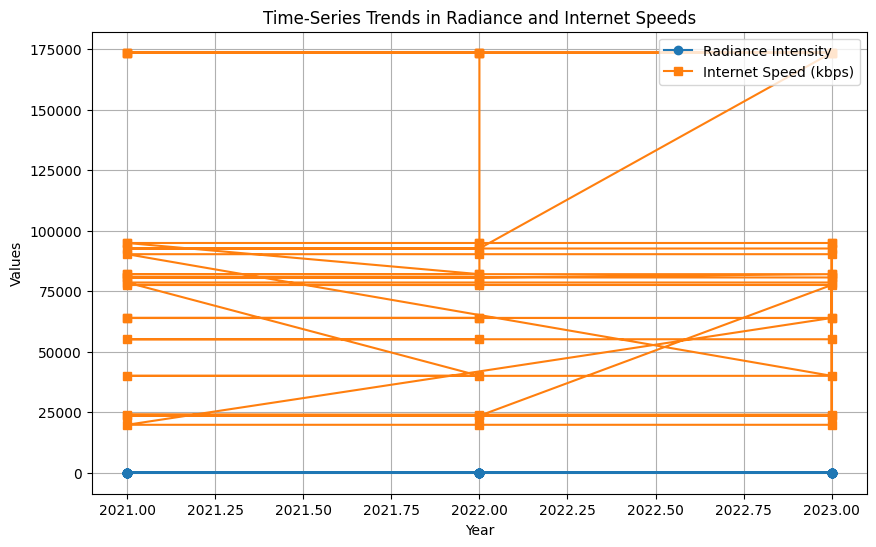

In [19]:
# Filter data for a specific region (latitude and longitude range)
region_data = data[(data['latitude'] > -5) & (data['latitude'] < 5) &
                   (data['longitude'] > 70) & (data['longitude'] < 75)]

# Plot trends over time
plt.figure(figsize=(10, 6))
plt.plot(region_data['year'], region_data['light intensity'], label='Radiance Intensity', marker='o')
plt.plot(region_data['year'], region_data['avg_d_kbps'], label='Internet Speed (kbps)', marker='s')
plt.title("Time-Series Trends in Radiance and Internet Speeds")
plt.xlabel("Year")
plt.ylabel("Values")
plt.legend()
plt.grid(True)
plt.show()


In [24]:
# Check missing values
print(data['percentage'].isnull().sum())

# Fill missing values with the column mean
data['percentage'].fillna(data['percentage'].mean(), inplace=True)


54


<ipython-input-24-86e03ea820f7>:5: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  data['percentage'].fillna(data['percentage'].mean(), inplace=True)


In [25]:
# Define features (predictors) and target (GDP growth)
X = data[['percentage', 'avg_d_kbps']]  # Predictors
y = data['GDP_at_Market_Price']         # Target variable


In [26]:
# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Check shapes of the splits
print(f"Training set size: {X_train.shape}")
print(f"Testing set size: {X_test.shape}")


Training set size: (113, 2)
Testing set size: (49, 2)


In [27]:
# Initialize the Linear Regression model
linear_model = LinearRegression()

# Train the model
linear_model.fit(X_train, y_train)

# Print coefficients and intercept
print("Model Coefficients:", linear_model.coef_)
print("Model Intercept:", linear_model.intercept_)


Model Coefficients: [-7.57688812e-02  8.87899800e-06]
Model Intercept: 22.884388986030455


In [28]:
# Predict GDP growth for the test set
y_pred = linear_model.predict(X_test)


In [29]:
# Calculate MSE and R²
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Mean Squared Error (MSE): {mse:.2f}")
print(f"R-squared (R²): {r2:.2f}")


Mean Squared Error (MSE): 581.25
R-squared (R²): -0.05


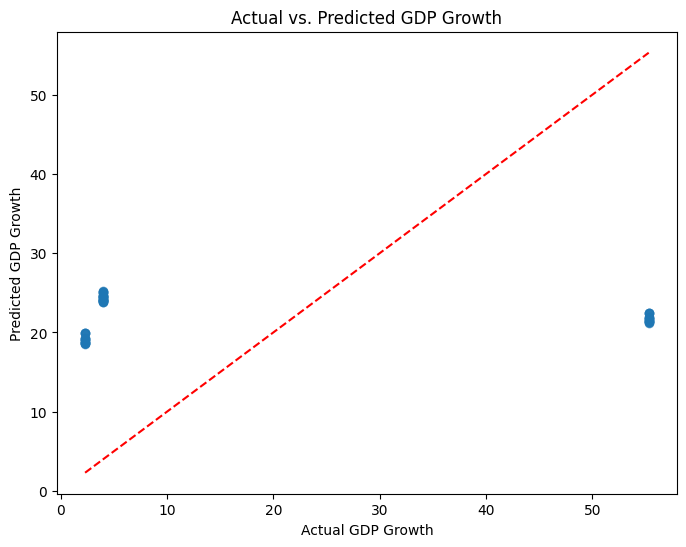

In [30]:
import matplotlib.pyplot as plt

# Plot actual vs. predicted values
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred, alpha=0.7)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')  # Line of perfect prediction
plt.xlabel("Actual GDP Growth")
plt.ylabel("Predicted GDP Growth")
plt.title("Actual vs. Predicted GDP Growth")
plt.show()


In [31]:
# Initialize the Random Forest Regressor
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)

# Train the model
rf_model.fit(X_train, y_train)

print("Random Forest model training completed.")


Random Forest model training completed.


In [32]:
# Predict GDP growth for the test set
y_pred_rf = rf_model.predict(X_test)

# Calculate MSE and R²
mse_rf = mean_squared_error(y_test, y_pred_rf)
r2_rf = r2_score(y_test, y_pred_rf)

print(f"Random Forest MSE: {mse_rf:.2f}")
print(f"Random Forest R²: {r2_rf:.2f}")


Random Forest MSE: 0.00
Random Forest R²: 1.00


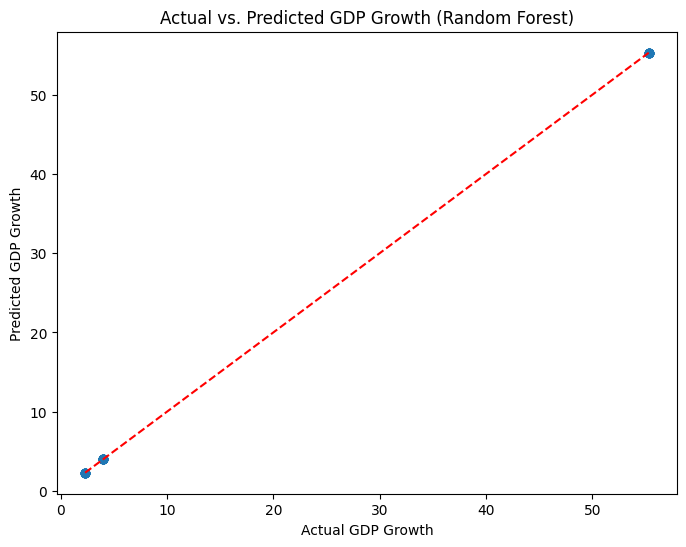

In [33]:
# Plot actual vs. predicted values
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred_rf, alpha=0.7)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')  # Line of perfect prediction
plt.xlabel("Actual GDP Growth")
plt.ylabel("Predicted GDP Growth")
plt.title("Actual vs. Predicted GDP Growth (Random Forest)")
plt.show()


In [34]:
print("Linear Regression Results:")
print(f"  MSE: {mse:.2f}")
print(f"  R²: {r2:.2f}")

print("\nRandom Forest Results:")
print(f"  MSE: {mse_rf:.2f}")
print(f"  R²: {r2_rf:.2f}")


Linear Regression Results:
  MSE: 581.25
  R²: -0.05

Random Forest Results:
  MSE: 0.00
  R²: 1.00


In [35]:
# Save the Random Forest model (or whichever performs better)
joblib.dump(rf_model, "gdp_prediction_model.pkl")
print("Model saved as 'gdp_prediction_model.pkl'")


Model saved as 'gdp_prediction_model.pkl'
